# NSCLC Datset Investigation

## Load Datasets

Downloaded 9 subsets of the whole atlas.

In [1]:
import pandas as pd
import scanpy as sc
from utils.io import read_anndata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dask import array as da
from tqdm.dask import TqdmCallback

from utils.io import read_anndata

adata_mucosal = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Matuck2024_mucosal.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

adata_pulp = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Matuck2024_pulp.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

adata_gland = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Matuck2024_gland.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

adata_minor_salivary_gland = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Matuck2024_minor_salivary_gland.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

adata_buccal_and_labial = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Matuck2024_buccal_and_labial.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

adata_major_salivary_gland = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Matuck2024_major_salivary_gland.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

adata_palate = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Matuck2024_palate.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

adata_mucosal_immune = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Matuck2024_mucosal_immune.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

adata_gland_immune = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Matuck2024_gland_immune.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

dask: False, backed: False
Read slot "obs", store as "obs"...


/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...
dask: False, backed: False
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...
dask: False, backed: False
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...
dask: False, backed: False
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...
dask: False, backed: False
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...
dask: False, backed: False
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...
dask: False, backed: False
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...
dask: False, backed: False
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as 

## Dataset Complexity

### Tissue

In [5]:
adata_mucosal.obs["tissue"].unique()

['mucosa of lip', 'buccal mucosa', 'gingiva', 'hard palate', 'soft palate']
Categories (5, object): ['soft palate', 'gingiva', 'hard palate', 'buccal mucosa', 'mucosa of lip']

In [6]:
adata_pulp.obs["tissue"].unique()

['dental pulp']
Categories (1, object): ['dental pulp']

In [7]:
adata_gland.obs["tissue"].unique()

['parotid gland', 'minor salivary gland', 'submandibular gland']
Categories (3, object): ['submandibular gland', 'minor salivary gland', 'parotid gland']

In [8]:
adata_minor_salivary_gland.obs["tissue"].unique()

['minor salivary gland']
Categories (1, object): ['minor salivary gland']

In [9]:
adata_buccal_and_labial.obs["tissue"].unique()

['mucosa of lip', 'buccal mucosa']
Categories (2, object): ['buccal mucosa', 'mucosa of lip']

In [10]:
adata_major_salivary_gland.obs["tissue"].unique()

['parotid gland', 'submandibular gland']
Categories (2, object): ['submandibular gland', 'parotid gland']

In [11]:
adata_palate.obs["tissue"].unique()

['hard palate', 'soft palate']
Categories (2, object): ['soft palate', 'hard palate']

In [12]:
adata_mucosal_immune.obs["tissue"].unique()

['buccal mucosa', 'soft palate', 'hard palate', 'gingiva']
Categories (4, object): ['soft palate', 'gingiva', 'hard palate', 'buccal mucosa']

In [13]:
adata_gland_immune.obs["tissue"].unique()

['minor salivary gland', 'submandibular gland', 'parotid gland']
Categories (3, object): ['submandibular gland', 'minor salivary gland', 'parotid gland']

### Number of cells and genes

In [14]:
adata_mucosal

AnnData object with n_obs × n_vars = 87000 × 36306
    obs: 'celltype', 'sample_id', 'study', 'niche', 'donor_id', 'protocol_url', 'institute', 'sample_collection_site', 'sample_collection_relative_time_point', 'library_id', 'library_id_repository', 'author_batch_notes', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'Region/Tooth #', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'cell_viability_percentage', 'cell_number_loaded', 'sample_collection_year', 'assay_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'ancestry', 'self_reported_ethnicity_ontology_term_id', 'age range', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'cell_type

In [15]:
adata_pulp

AnnData object with n_obs × n_vars = 50927 × 36306
    obs: 'celltype', 'sample_id', 'study', 'niche', 'donor_id', 'protocol_url', 'institute', 'sample_collection_site', 'sample_collection_relative_time_point', 'library_id', 'library_id_repository', 'author_batch_notes', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'Region/Tooth #', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'cell_viability_percentage', 'cell_number_loaded', 'sample_collection_year', 'assay_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'ancestry', 'self_reported_ethnicity_ontology_term_id', 'age range', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'cell_type

In [16]:
adata_gland

AnnData object with n_obs × n_vars = 50240 × 36306
    obs: 'celltype', 'sample_id', 'study', 'niche', 'donor_id', 'protocol_url', 'institute', 'sample_collection_site', 'sample_collection_relative_time_point', 'library_id', 'library_id_repository', 'author_batch_notes', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'Region/Tooth #', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'cell_viability_percentage', 'cell_number_loaded', 'sample_collection_year', 'assay_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'ancestry', 'self_reported_ethnicity_ontology_term_id', 'age range', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'cell_type

In [17]:
adata_minor_salivary_gland

AnnData object with n_obs × n_vars = 31468 × 36306
    obs: 'celltype', 'sample_id', 'study', 'niche', 'donor_id', 'protocol_url', 'institute', 'sample_collection_site', 'sample_collection_relative_time_point', 'library_id', 'library_id_repository', 'author_batch_notes', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'Region/Tooth #', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'cell_viability_percentage', 'cell_number_loaded', 'sample_collection_year', 'assay_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'ancestry', 'self_reported_ethnicity_ontology_term_id', 'age range', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'cell_type

In [18]:
adata_buccal_and_labial

AnnData object with n_obs × n_vars = 29478 × 36306
    obs: 'celltype', 'sample_id', 'study', 'niche', 'donor_id', 'protocol_url', 'institute', 'sample_collection_site', 'sample_collection_relative_time_point', 'library_id', 'library_id_repository', 'author_batch_notes', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'Region/Tooth #', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'cell_viability_percentage', 'cell_number_loaded', 'sample_collection_year', 'assay_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'ancestry', 'self_reported_ethnicity_ontology_term_id', 'age range', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'cell_type

In [19]:
adata_major_salivary_gland

AnnData object with n_obs × n_vars = 18772 × 36306
    obs: 'celltype', 'sample_id', 'study', 'niche', 'donor_id', 'protocol_url', 'institute', 'sample_collection_site', 'sample_collection_relative_time_point', 'library_id', 'library_id_repository', 'author_batch_notes', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'Region/Tooth #', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'cell_viability_percentage', 'cell_number_loaded', 'sample_collection_year', 'assay_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'ancestry', 'self_reported_ethnicity_ontology_term_id', 'age range', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'cell_type

In [20]:
adata_palate

AnnData object with n_obs × n_vars = 9263 × 36306
    obs: 'celltype', 'sample_id', 'study', 'niche', 'donor_id', 'protocol_url', 'institute', 'sample_collection_site', 'sample_collection_relative_time_point', 'library_id', 'library_id_repository', 'author_batch_notes', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'Region/Tooth #', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'cell_viability_percentage', 'cell_number_loaded', 'sample_collection_year', 'assay_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'ancestry', 'self_reported_ethnicity_ontology_term_id', 'age range', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'cell_type'

In [21]:
adata_mucosal_immune

AnnData object with n_obs × n_vars = 23064 × 36306
    obs: 'celltype', 'sample_id', 'study', 'niche', 'donor_id', 'protocol_url', 'institute', 'sample_collection_site', 'sample_collection_relative_time_point', 'library_id', 'library_id_repository', 'author_batch_notes', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'Region/Tooth #', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'cell_viability_percentage', 'cell_number_loaded', 'sample_collection_year', 'assay_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'ancestry', 'self_reported_ethnicity_ontology_term_id', 'age range', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'cell_type

In [22]:
adata_gland_immune

AnnData object with n_obs × n_vars = 6362 × 36306
    obs: 'celltype', 'sample_id', 'study', 'niche', 'donor_id', 'protocol_url', 'institute', 'sample_collection_site', 'sample_collection_relative_time_point', 'library_id', 'library_id_repository', 'author_batch_notes', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'Region/Tooth #', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'cell_viability_percentage', 'cell_number_loaded', 'sample_collection_year', 'assay_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'ancestry', 'self_reported_ethnicity_ontology_term_id', 'age range', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'cell_type'

### Cell Types

In [24]:
adata_mucosal.obs["celltype"].nunique()

22

In [25]:
adata_gland.obs["celltype"].nunique()

19

In [26]:
adata_pulp.obs["celltype"].nunique()

13

In [27]:
adata_minor_salivary_gland.obs["celltype"].nunique()

18

In [29]:
adata_buccal_and_labial.obs["celltype"].nunique()

19

In [30]:
adata_major_salivary_gland.obs["celltype"].nunique()

16

In [31]:
adata_palate.obs["celltype"].nunique()

18

In [32]:
adata_mucosal_immune.obs["celltype"].nunique()

9

In [33]:
adata_gland_immune.obs["celltype"].nunique()

8

## Batch Complexity

### Nested batches

What did they consider as batches? They don't speicify it on their paper.

In [35]:
adata_mucosal.obs.columns

Index(['celltype', 'sample_id', 'study', 'niche', 'donor_id', 'protocol_url',
       'institute', 'sample_collection_site',
       'sample_collection_relative_time_point', 'library_id',
       'library_id_repository', 'author_batch_notes', 'manner_of_death',
       'sample_source', 'sex_ontology_term_id', 'sample_collection_method',
       'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id',
       'Region/Tooth #', 'sample_preservation_method', 'suspension_type',
       'cell_enrichment', 'cell_viability_percentage', 'cell_number_loaded',
       'sample_collection_year', 'assay_ontology_term_id',
       'library_preparation_batch', 'library_sequencing_run',
       'sequenced_fragment', 'sequencing_platform', 'is_primary_data',
       'reference_genome', 'gene_annotation_version', 'alignment_software',
       'intron_inclusion', 'disease_ontology_term_id', 'ancestry',
       'self_reported_ethnicity_ontology_term_id', 'age range',
       'development_stage_ontology_term_

I'll take sample_id, donor_id, library_id

In [37]:
adata_mucosal.obs[["library_id", "donor_id"]].drop_duplicates().value_counts("library_id")

library_id
BM152          1
BM156          1
BM157          1
BM158          1
BM165          1
BM168          1
BM169          1
GM136          1
GM143          1
GM144          1
GM148          1
GM183          1
GM184          1
GM238          1
GM241          1
GM242          1
GM283          1
GM289          1
Healthy1       1
Healthy2       1
Muc22          1
Muc23          1
Muc24          1
Muc25          1
Muc26          1
N/A            1
replicate 1    1
replicate 2    1
Name: count, dtype: int64

In [38]:
adata_mucosal.obs[["library_id", "donor_id"]].drop_duplicates().value_counts("donor_id")

donor_id
Caetano_Healthy1    1
Caetano_Healthy2    1
Ko_replicate 1      1
Ko_replicate 2      1
Kretzschmar_1       1
Warner_3629         1
Warner_3630         1
Warner_3631         1
Warner_3632         1
Warner_3633         1
Williams_BM152      1
Williams_BM156      1
Williams_BM157      1
Williams_BM158      1
Williams_BM165      1
Williams_BM168      1
Williams_BM169      1
Williams_GM136      1
Williams_GM143      1
Williams_GM144      1
Williams_GM148      1
Williams_GM183      1
Williams_GM184      1
Williams_GM238      1
Williams_GM241      1
Williams_GM242      1
Williams_GM283      1
Williams_GM289      1
Name: count, dtype: int64

library - donor is 1:1

In [39]:
adata_mucosal.obs[["sample_id", "donor_id"]].drop_duplicates().value_counts("sample_id")

sample_id
B2     1
B3     1
B4     1
B5     1
B6     1
B7     1
B8     1
G1     1
G2     1
G3     1
G5     1
G7     1
G8     1
G9     1
G10    1
G11    1
G12    1
G13    1
G14    1
G15    1
HP1    1
HP2    1
L1     1
L2     1
L3     1
L4     1
L5     1
SP1    1
Name: count, dtype: int64

In [40]:
adata_mucosal.obs[["sample_id", "donor_id"]].drop_duplicates().value_counts("donor_id")

donor_id
Caetano_Healthy1    1
Caetano_Healthy2    1
Ko_replicate 1      1
Ko_replicate 2      1
Kretzschmar_1       1
Warner_3629         1
Warner_3630         1
Warner_3631         1
Warner_3632         1
Warner_3633         1
Williams_BM152      1
Williams_BM156      1
Williams_BM157      1
Williams_BM158      1
Williams_BM165      1
Williams_BM168      1
Williams_BM169      1
Williams_GM136      1
Williams_GM143      1
Williams_GM144      1
Williams_GM148      1
Williams_GM183      1
Williams_GM184      1
Williams_GM238      1
Williams_GM241      1
Williams_GM242      1
Williams_GM283      1
Williams_GM289      1
Name: count, dtype: int64

In [41]:
adata_mucosal.obs[["sample_id", "library_id"]].drop_duplicates().value_counts("sample_id")

sample_id
B2     1
B3     1
B4     1
B5     1
B6     1
B7     1
B8     1
G1     1
G2     1
G3     1
G5     1
G7     1
G8     1
G9     1
G10    1
G11    1
G12    1
G13    1
G14    1
G15    1
HP1    1
HP2    1
L1     1
L2     1
L3     1
L4     1
L5     1
SP1    1
Name: count, dtype: int64

In [42]:
adata_mucosal.obs[["sample_id", "library_id"]].drop_duplicates().value_counts("library_id")

library_id
BM152          1
BM156          1
BM157          1
BM158          1
BM165          1
BM168          1
BM169          1
GM136          1
GM143          1
GM144          1
GM148          1
GM183          1
GM184          1
GM238          1
GM241          1
GM242          1
GM283          1
GM289          1
Healthy1       1
Healthy2       1
Muc22          1
Muc23          1
Muc24          1
Muc25          1
Muc26          1
N/A            1
replicate 1    1
replicate 2    1
Name: count, dtype: int64

sample - library, sample - donor are also 1:1

=> The dataset does NOT have batch hirearchy. I will pick library_id as the batch.

In [6]:
adata_mucosal.obs["library_id"].cat.categories

Index(['BM152', 'BM156', 'BM157', 'BM158', 'BM165', 'BM168', 'BM169', 'GM136',
       'GM143', 'GM144', 'GM148', 'GM183', 'GM184', 'GM238', 'GM241', 'GM242',
       'GM283', 'GM289', 'Healthy1', 'Healthy2', 'Muc22', 'Muc23', 'Muc24',
       'Muc25', 'Muc26', 'N/A', 'replicate 1', 'replicate 2'],
      dtype='object')

### Number of Batches

In [43]:
adata_mucosal.obs["library_id"].nunique()

28

In [44]:
adata_pulp.obs["library_id"].nunique()

12

In [45]:
adata_gland.obs["library_id"].nunique()

14

In [46]:
adata_minor_salivary_gland.obs["library_id"].nunique()

9

In [48]:
adata_buccal_and_labial.obs["library_id"].nunique()

12

In [49]:
adata_major_salivary_gland.obs["library_id"].nunique()

5

In [50]:
adata_palate.obs["library_id"].nunique()

3

In [51]:
adata_mucosal_immune.obs["library_id"].nunique()

27

In [52]:
adata_gland_immune.obs["library_id"].nunique()

12

### Batch Size Imbalance

In [57]:
batch_size = adata_mucosal.obs["library_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 3107.14
Standard deviation: 2668.14
Minimum batch size: 150
Maximum batch size: 8611
Coefficient of variance: 0.86


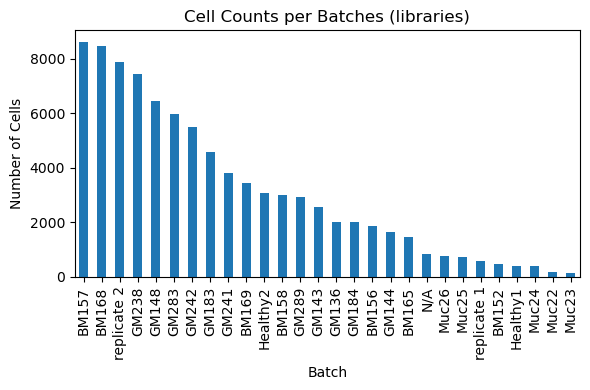

In [58]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (libraries)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [59]:
batch_size = adata_pulp.obs["library_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 4243.92
Standard deviation: 2935.37
Minimum batch size: 393
Maximum batch size: 10895
Coefficient of variance: 0.69


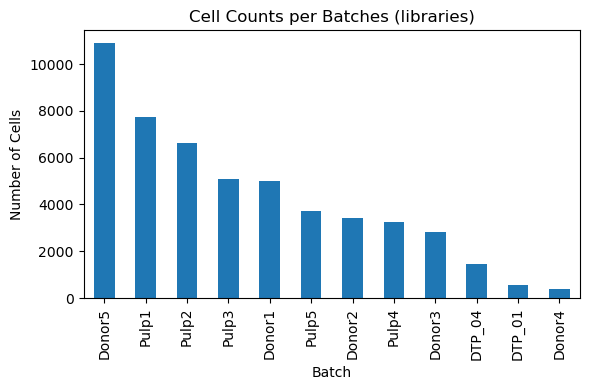

In [60]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (libraries)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [61]:
batch_size = adata_gland.obs["library_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 3588.57
Standard deviation: 3159.48
Minimum batch size: 42
Maximum batch size: 10842
Coefficient of variance: 0.88


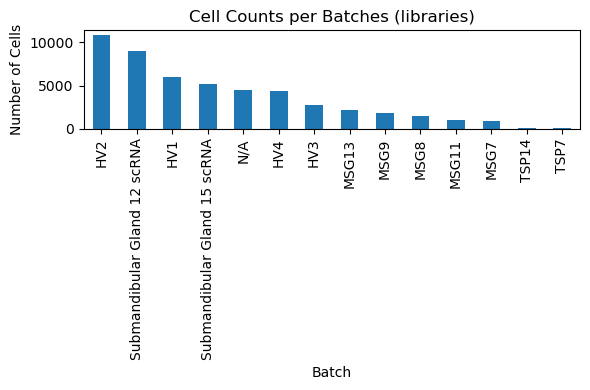

In [62]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (libraries)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [63]:
batch_size = adata_minor_salivary_gland.obs["library_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 3496.44
Standard deviation: 3033.57
Minimum batch size: 904
Maximum batch size: 10842
Coefficient of variance: 0.87


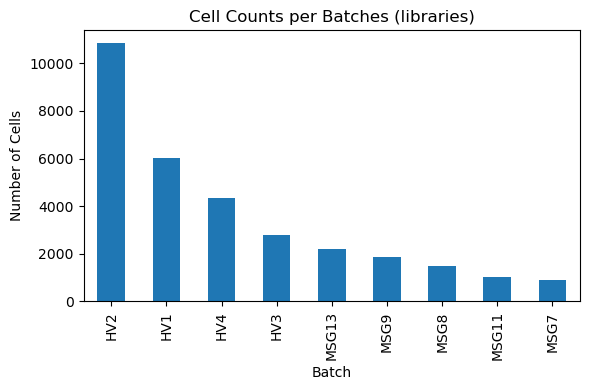

In [64]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (libraries)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [65]:
batch_size = adata_buccal_and_labial.obs["library_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 2456.50
Standard deviation: 2903.49
Minimum batch size: 150
Maximum batch size: 8611
Coefficient of variance: 1.18


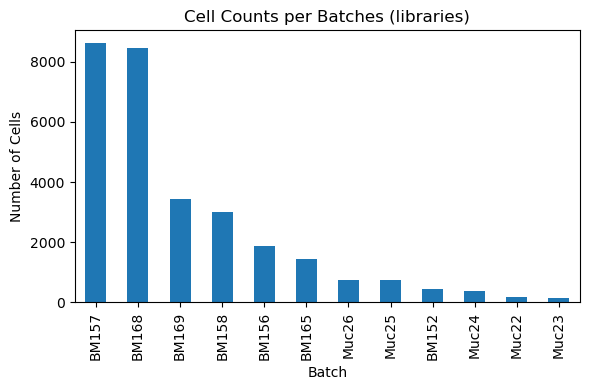

In [66]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (libraries)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [67]:
batch_size = adata_major_salivary_gland.obs["library_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 3754.40
Standard deviation: 3367.96
Minimum batch size: 42
Maximum batch size: 8952
Coefficient of variance: 0.90


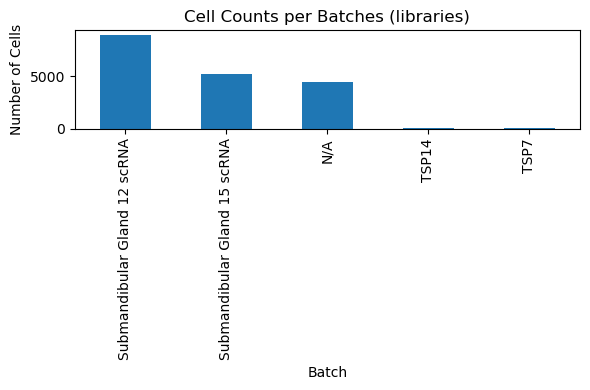

In [68]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (libraries)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [69]:
batch_size = adata_palate.obs["library_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 3087.67
Standard deviation: 3378.36
Minimum batch size: 569
Maximum batch size: 7863
Coefficient of variance: 1.09


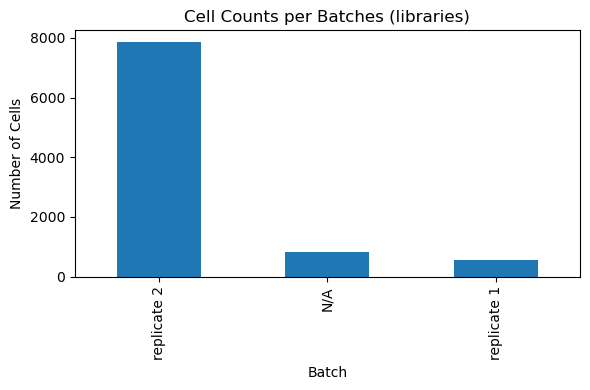

In [70]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (libraries)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [71]:
batch_size = adata_mucosal_immune.obs["library_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 854.22
Standard deviation: 735.44
Minimum batch size: 101
Maximum batch size: 2905
Coefficient of variance: 0.86


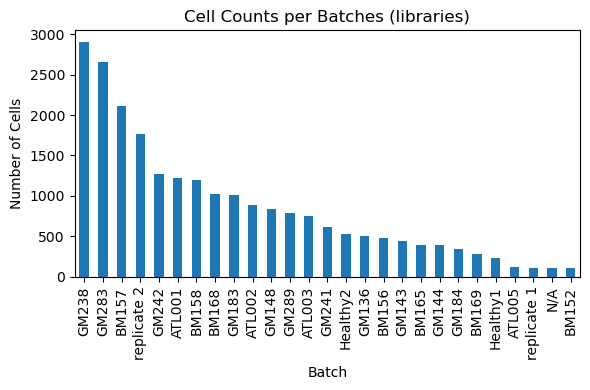

In [72]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (libraries)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [73]:
batch_size = adata_gland_immune.obs["library_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 530.17
Standard deviation: 471.86
Minimum batch size: 122
Maximum batch size: 1832
Coefficient of variance: 0.89


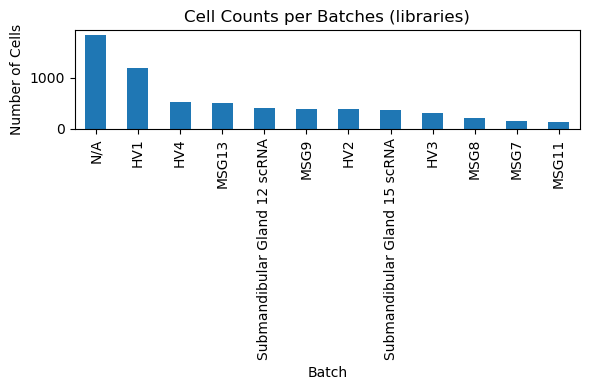

In [74]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (libraries)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Number and Size of Samples

In [78]:
adata_mucosal.obs["sample_id"].nunique()

28

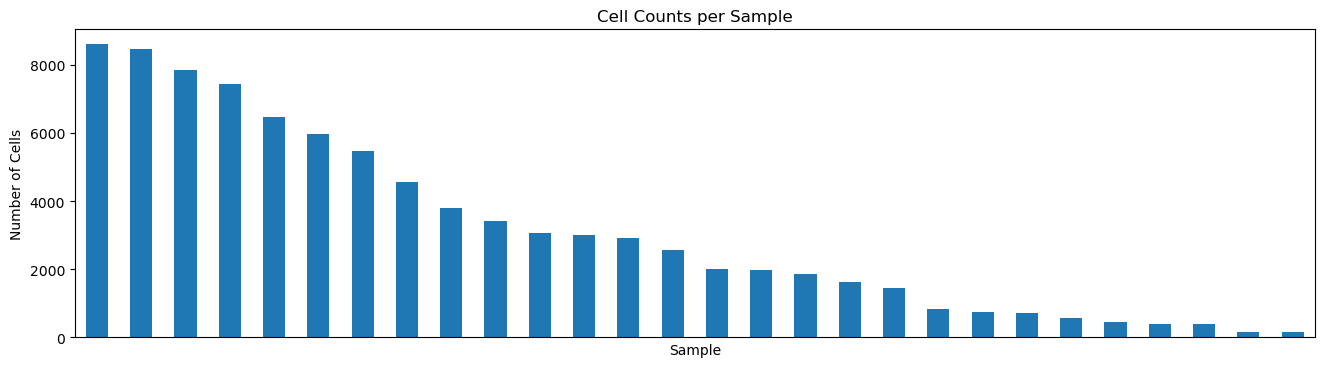

In [79]:
sample_size = adata_mucosal.obs["sample_id"].value_counts()
plt.figure(figsize=(16, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.xticks([])
plt.show()

In [80]:
adata_pulp.obs["sample_id"].nunique()

12

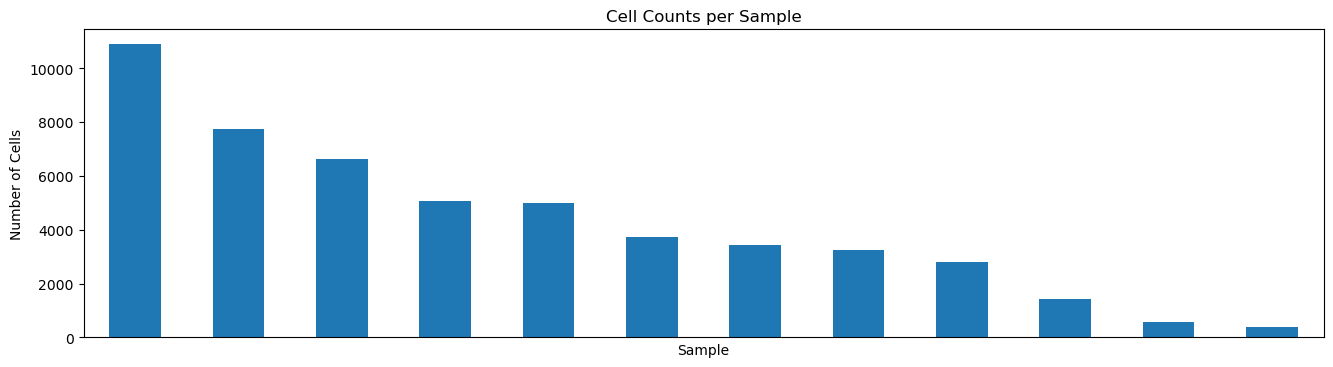

In [83]:
sample_size = adata_pulp.obs["sample_id"].value_counts()
plt.figure(figsize=(16, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.xticks([])
plt.show()

In [82]:
adata_gland.obs["sample_id"].nunique()

15

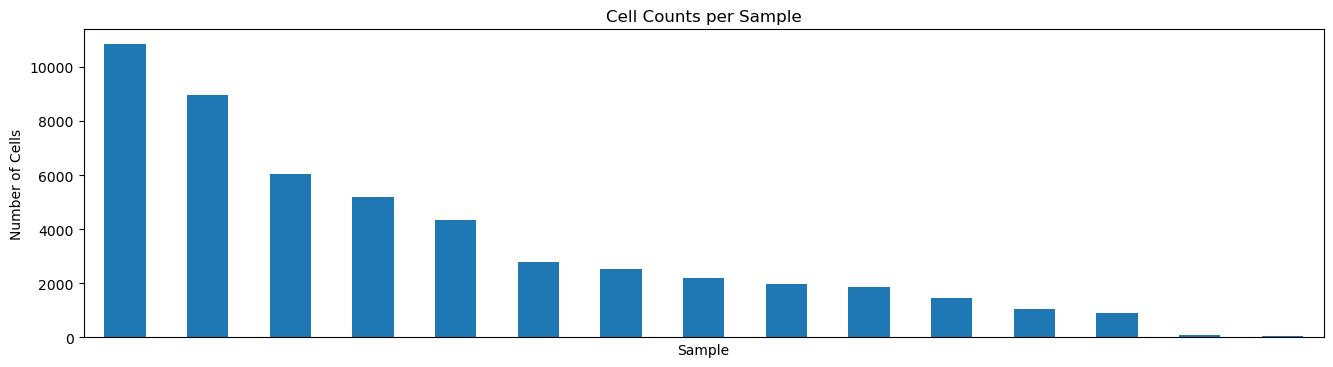

In [84]:
sample_size = adata_gland.obs["sample_id"].value_counts()
plt.figure(figsize=(16, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.xticks([])
plt.show()

In [85]:
adata_minor_salivary_gland.obs["sample_id"].nunique()

9

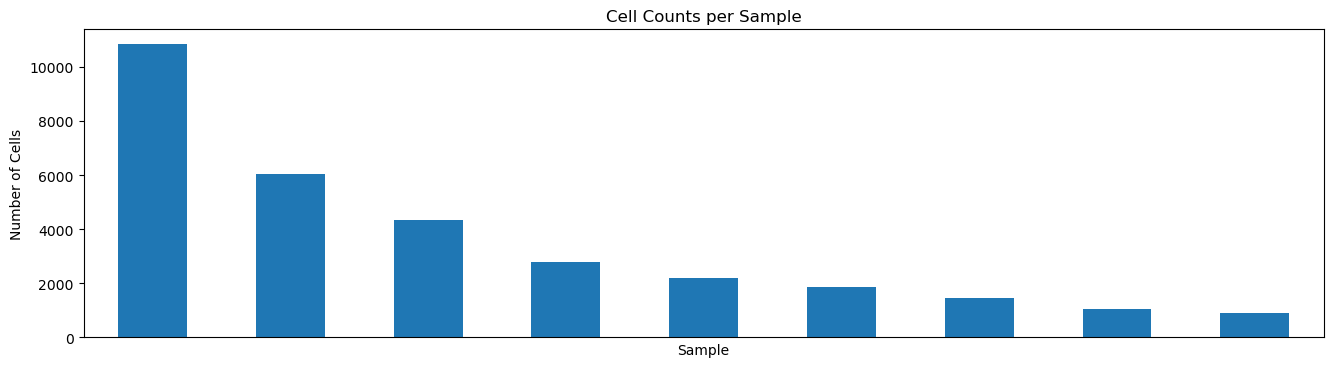

In [86]:
sample_size = adata_minor_salivary_gland.obs["sample_id"].value_counts()
plt.figure(figsize=(16, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.xticks([])
plt.show()

In [87]:
adata_buccal_and_labial.obs["sample_id"].nunique()

12

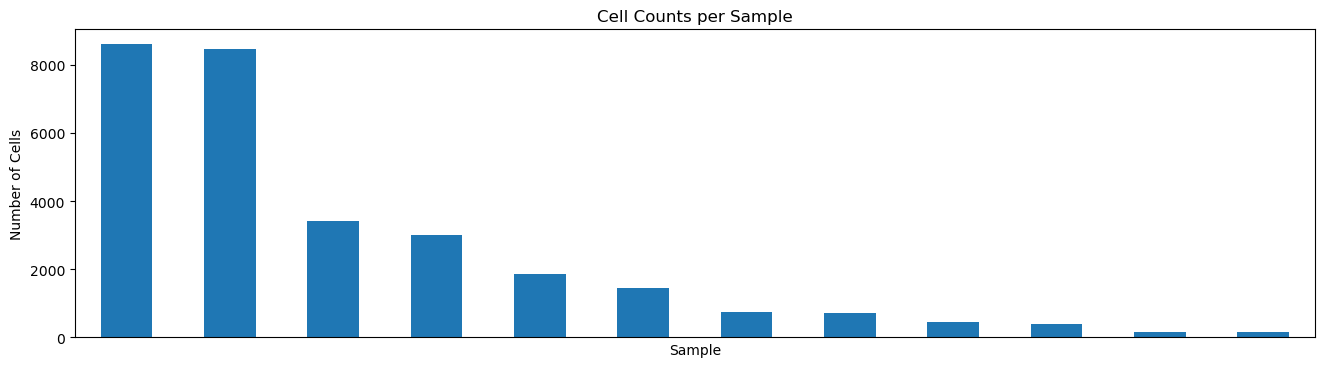

In [88]:
sample_size = adata_buccal_and_labial.obs["sample_id"].value_counts()
plt.figure(figsize=(16, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.xticks([])
plt.show()

In [89]:
adata_major_salivary_gland.obs["sample_id"].nunique()

6

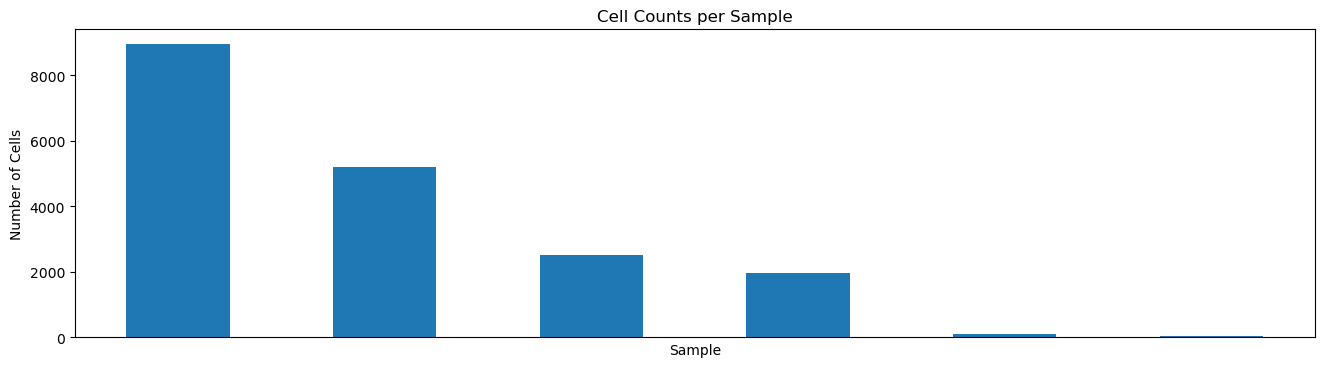

In [90]:
sample_size = adata_major_salivary_gland.obs["sample_id"].value_counts()
plt.figure(figsize=(16, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.xticks([])
plt.show()

In [91]:
adata_palate.obs["sample_id"].nunique()

3

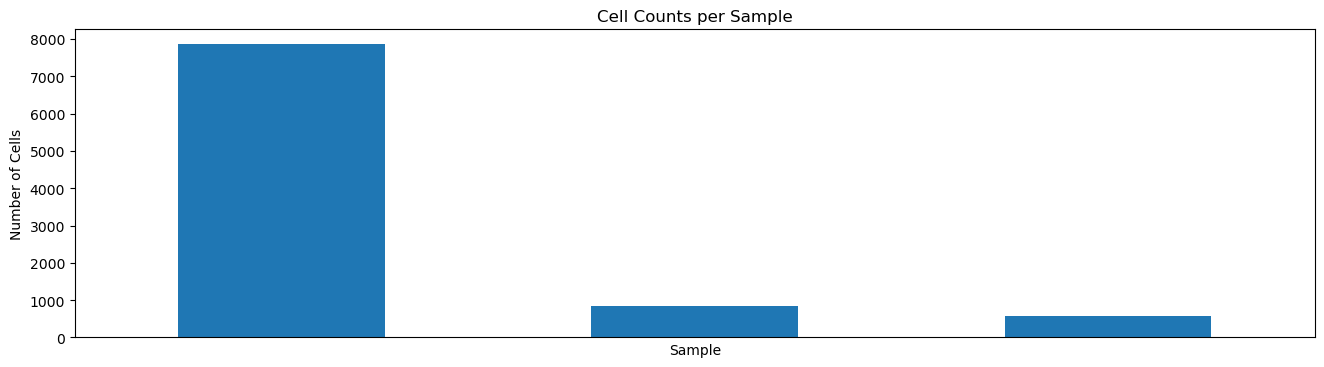

In [92]:
sample_size = adata_palate.obs["sample_id"].value_counts()
plt.figure(figsize=(16, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.xticks([])
plt.show()

In [93]:
adata_mucosal_immune.obs["sample_id"].nunique()

27

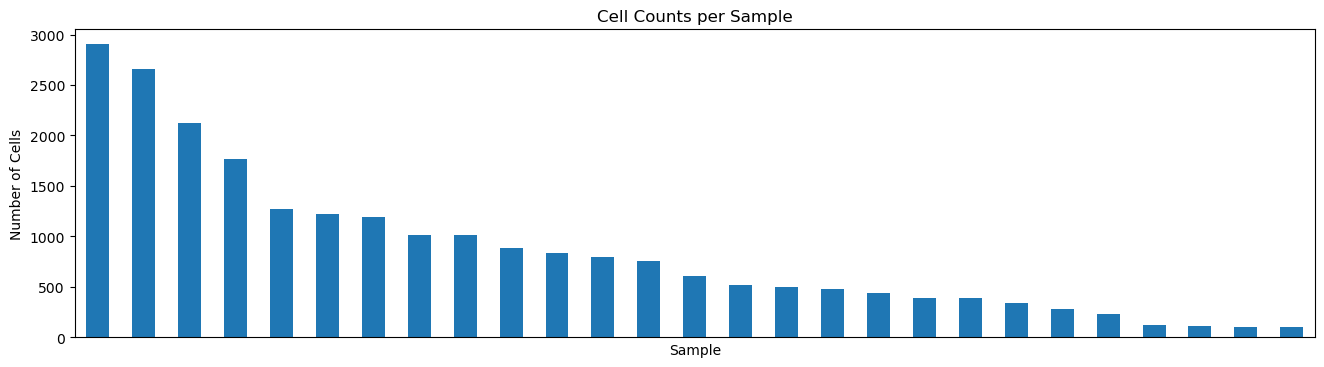

In [94]:
sample_size = adata_mucosal_immune.obs["sample_id"].value_counts()
plt.figure(figsize=(16, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.xticks([])
plt.show()

In [95]:
adata_gland_immune.obs["sample_id"].nunique()

13

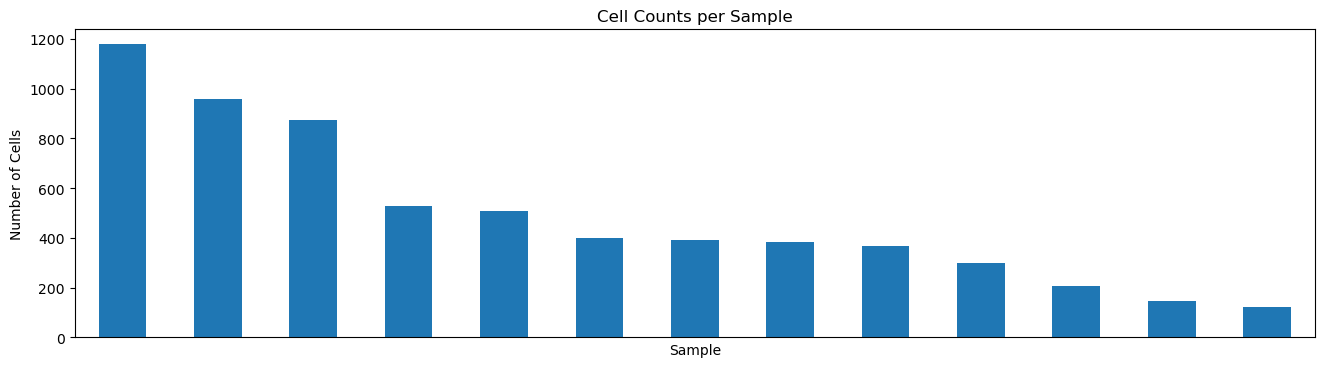

In [96]:
sample_size = adata_gland_immune.obs["sample_id"].value_counts()
plt.figure(figsize=(16, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.xticks([])
plt.show()

### Number of Donors

Same as the number of samples, since they're in 1:1 relationship

### Number of Cohorts

In [100]:
adata_mucosal.obs["study"].nunique()

5

In [102]:
adata_pulp.obs["study"].nunique()

3

In [103]:
adata_gland.obs["study"].nunique()

5

In [104]:
adata_minor_salivary_gland.obs["study"].nunique()

2

In [105]:
adata_buccal_and_labial.obs["study"].nunique()

2

In [106]:
adata_major_salivary_gland.obs["study"].nunique()

3

In [107]:
adata_palate.obs["study"].nunique()

2

In [108]:
adata_mucosal_immune.obs["study"].nunique()

5

In [109]:
adata_gland_immune.obs["study"].nunique()

4